IMPORTS

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


TRAIN_TEST_SPLIT

In [2]:
def make_train_valid_dfs(): #This functions splits the dataset into training and testing using sklearn libraray
    df = pd.read_excel(r"C:/Users/haZAR/Desktop/Clustering.xlsx")  # Read the Excel file
    train, test = train_test_split(df, test_size=0.8, train_size=0.2, shuffle=True, random_state=77, stratify=None)
    return train, test

df_val, df = make_train_valid_dfs()

SPLITTING_TIMESTAMP

In [3]:
'''EXTRACTION OF YEAR,MONTH,DAY..... FROM TIMESTAMPS GIVEN IN TRAINING DATASET'''

df['year'] = df['TimeStamp'].dt.year
df['month'] = df['TimeStamp'].dt.month
df['day'] = df['TimeStamp'].dt.day
df['hour'] = df['TimeStamp'].dt.hour
df['minute'] = df['TimeStamp'].dt.minute
df['second'] = df['TimeStamp'].dt.second

# List of columns to drop
columns_to_drop = ['TimeStamp', 'second', 'year']
# Drop the specified columns
df = df.drop(columns=columns_to_drop)
# Filter out rows with 'Power Generated' equal to or less than zero
df = df[df['Power Generated'] > 0]

'''EXTRACTION OF YEAR,MONTH,DAY..... FROM TIMESTAMPS GIVEN IN VALIDATION DATASET'''

df_val['year'] = df_val['TimeStamp'].dt.year
df_val['month'] = df_val['TimeStamp'].dt.month
df_val['day'] = df_val['TimeStamp'].dt.day
df_val['hour'] = df_val['TimeStamp'].dt.hour
df_val['minute'] = df_val['TimeStamp'].dt.minute
df_val['second'] = df_val['TimeStamp'].dt.second
df_val = df_val.drop(columns=columns_to_drop)
df_val = df_val[df_val['Power Generated'] > 0]

MODEL

c:\Users\haZAR\anaconda3\envs\pytorchgpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


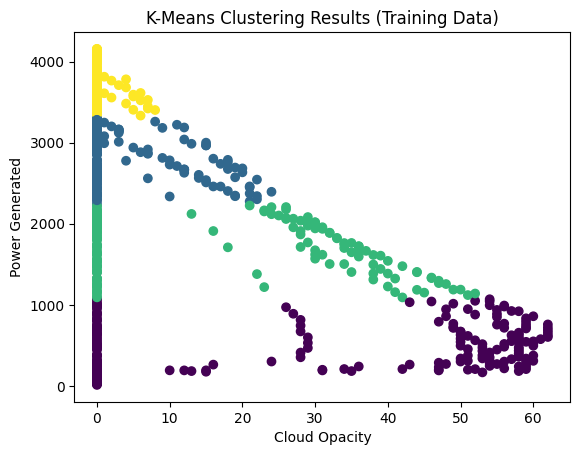

In [4]:
# Initialize the KMeans algorithm with 4 clusters and a fixed random state for reproducibility
kmeans = KMeans(n_clusters=4, random_state=77)

# Fit the KMeans algorithm to the dataframe 'df' to perform the clustering
kmeans.fit(df)

# The 'fit' method optimizes the positions of the centroids (cluster centers) to minimize the within-cluster sum of squares,
# which quantifies the variance within each cluster. This process iteratively adjusts the centroids to find the best clustering.

# Assign the cluster labels generated by kmeans to a new column in 'df' called 'cluster'
df['cluster'] = kmeans.labels_

# Visualize the clustering results on the training data
# Plotting 'cloud_opacity' vs 'Power Generated' and coloring the points by their cluster assignment
plt.scatter(df['cloud_opacity'], df['Power Generated'], c=df['cluster'], cmap='viridis')
plt.xlabel('Cloud Opacity')  # Label for the x-axis
plt.ylabel('Power Generated')  # Label for the y-axis
plt.title('K-Means Clustering Results (Training Data)')  # Title of the plot
plt.show()  # Display the plot

VALIDATING

Silhouette Score: 0.5857915299347445
Davies-Bouldin Index: 0.4791453351517579


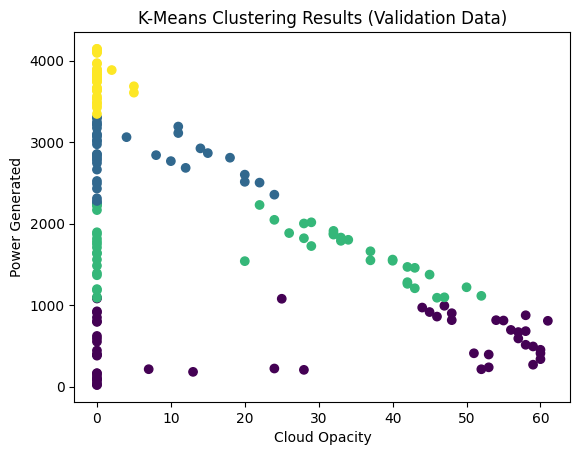

In [5]:
# Assign cluster labels to the validation dataset using the trained kmeans model
df_val['cluster'] = kmeans.predict(df_val)

# Import necessary metrics for cluster evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate the Silhouette Score for the validation dataset
# The Silhouette Score is a measure of how similar an object is to its own cluster compared to other clusters.
# The score ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
silhouette_avg = silhouette_score(df_val.drop(columns=['cluster']), df_val['cluster'])

# Calculate the Davies-Bouldin Index for the validation dataset
# The Davies-Bouldin Index is a measure of the average similarity between each cluster and its most similar cluster, where similarity is the ratio of within-cluster distances to between-cluster distances.
# Lower values of the index indicate better clustering.
davies_bouldin_avg = davies_bouldin_score(df_val.drop(columns=['cluster']), df_val['cluster'])

# Print the calculated Silhouette Score and Davies-Bouldin Index
print(f'Silhouette Score: {silhouette_avg}')
print(f'Davies-Bouldin Index: {davies_bouldin_avg}')

# Visualize the clustering results on the validation data
# Plotting 'cloud_opacity' vs 'Power Generated' and coloring the points by their cluster assignment
plt.scatter(df_val['cloud_opacity'], df_val['Power Generated'], c=df_val['cluster'], cmap='viridis')
plt.xlabel('Cloud Opacity')  # Label for the x-axis
plt.ylabel('Power Generated')  # Label for the y-axis
plt.title('K-Means Clustering Results (Validation Data)')  # Title of the plot
plt.show()  # Display the plot